1. Lire les fichiers BIN, conversion dans la bonne unité et transformer en AC
2. Récuperer les annotations
3. Associer annotations fichier excel et valeurs des fichiers BIN (fait dans 1. et 2.)
4. Entrainement de Random Forest : (split en train et test, application de RF au train puis au test)
5. Analyser des résultats (matrices de confusion, accuracy score)

In [ ]:
import os
import struct
import csv
import pandas as pd
import numpy as np
import matplotlib as plt
import openpyxl
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import KMeans
from agcounts_filter import convert_AC
from datetime import datetime
from scipy.stats import mode

1-4 Récupération de X et Y 

In [9]:
temps_depart = datetime.now()

folder_path = "C:/Users/roman/Documents/BEaCHILD/X_et_Y" 
folder = os.listdir(folder_path)



# Initialisation des listes contenant les données des capteurs
X_non_dom = []
X_dom = []
idx_X_non_dom = 0
idx_X_dom = 0
idx_Y_dom = 0
idx_Y_non_dom = 0

# Initialisation des listes contenant les annotations vidéos
Y_non_dom = [] 
Y_dom = []


#Parcourir les fichiers CSV
for file in folder: #[0:7]
    print(f"On est dans le fichier : {file}")

    # Extension du fichier
    extension = os.path.splitext(file)[1] 

    # Pour les cas ou il y a des annotations avant le start
    allow_start_dom = None
    allow_start_non_dom = None

    """********************************************************************** 1. Lecture des fichiers csv ******************************************************************************"""
    if extension == ".csv":

        # Visualisation des données des capteurs
        data_file = pd.read_csv(folder_path + "/" + file, header = 5, names = ["Timestamp","Gyro X","Gyro Y","Gyro Z","Accelerometer X","Accelerometer Y","Accelerometer Z","Event","Quat W","Quat X","Quat Y","Quat Z","None"])    

        # Conversion en AC 
        dom_AC = convert_AC(folder_path + "/" + file)

        # Enregistrement des données des capteurs dans les listes qui seront donnnées au classificateur
        if file[-11:-4] == "non_dom":
            list_dom_AC = dom_AC["AC"].tolist() # Conversion du type pd.serie en type list
            for ac in list_dom_AC :
                X_non_dom.append(ac)

        elif file[-7:-4] == "dom":
            list_dom_AC = dom_AC["AC"].tolist()
            for ac in list_dom_AC:
                X_dom.append(ac)

    """********************************************************** 2. Enregistrer les annotations ***************************************************************************"""

    if extension == ".xlsx":

        start_dom = True
        start_non_dom = True 

        my_wb = openpyxl.load_workbook(folder_path + "/" + file) 
        my_sheet = my_wb.active

        # Initialisation des décalages : sert pour éviter le décalage du aux arrondis des annotations 
        decalage_dom = 0
        decalage_non_dom = 0

        for label in my_sheet["H"]: 

            """*********************************************** Récupération du début de Y ****************************************************"""
            # dom
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == "Start_RW" :
                if int(round(float(my_sheet.cell(label.row, 12).value))) < float(my_sheet.cell(label.row, 12).value):
                    start_sensor = int(round(float(my_sheet.cell(label.row, 12).value))) + 1
                else:
                    start_sensor = int(round(float(my_sheet.cell(label.row, 12).value))) 
                decalage_dom += start_sensor - float(my_sheet.cell(label.row, 12).value)

                for decalage in range(start_sensor):
                    Y_dom.append(None) #.append("différent start droit")
                previous_row_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_dom = True

            # non_dom 
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == "Start_non_dom" :
                if int(round(float(my_sheet.cell(label.row, 12).value))) < float(my_sheet.cell(label.row, 12).value):
                    start_sensor = int(round(float(my_sheet.cell(label.row, 12).value))) + 1
                else:
                    start_sensor = int(round(float(my_sheet.cell(label.row, 12).value))) 
                decalage_non_dom += start_sensor - float(my_sheet.cell(label.row, 12).value)
                #Ajouter un nb start_sensor de none au début
                for decalage in range(start_sensor):
                    Y_non_dom.append(None) #append("différent start gauche")
                previous_row_non_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_non_dom = True

            """****************************************************** Récupération du contenu de Y ****************************************"""

            if label.value[0:2] == "RW" and allow_start_dom:

                # Récupération de l'index de la ligne
                row = label.row

                # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_dom, 13).value:
                    difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_dom , 13).value)) 
                    for diff in range(0,difference):
                        Y_dom.append(None) #.append("décalage annotations")
                    
                # Synchronisation des données des capteurs avec les annotations
                nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value))) 
                for nb_sec in range(nb_repetitions): 
                    if X_dom and (len(Y_dom) == len(X_dom)) :
                        break
                    if label.value[3:13] == "sédentaire":
                        # Y_dom[idx_Y_dom].append("non mouvement")
                        Y_dom.append("non mouvement")
                    elif label.value[3:7] =="mouv":
                        #Y_dom[idx_Y_dom].append("mouvement")
                        Y_dom.append("mouvement")
                    elif label.value[3:12] == "non noté":
                        #Y_dom[idx_Y_dom].append("non noté") #.append(None) 
                        Y_dom.append(None) #("non noté")

                #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                previous_row_dom = label.row


            elif label.value[0:2] == "LW" and allow_start_non_dom:
                
                # Récupération de l'index de la ligne
                row = label.row

                # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_non_dom, 13).value:
                    difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_non_dom , 13).value)) 
                    for diff in range(0,difference):
                        Y_non_dom.append(None) #.append("décalage annotations")

                # Synchronisation des données des capteurs avec les annotations
                nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value)))
                for nb_sec in range(nb_repetitions): 
                    if X_non_dom and (len(Y_non_dom) == len(X_non_dom)): 
                        break
                    if label.value[3:13] == "sédentaire":
                        Y_non_dom.append("non mouvement")
                    elif label.value[3:7] =="mouv":
                        Y_non_dom.append("mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_non_dom.append(None)

                #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                previous_row_non_dom = label.row
        
        # CROPER X A L ALONGUEUR DE Y 
        X_dom = X_dom[:len(Y_dom)]
        X_non_dom = X_non_dom[:len(Y_non_dom)]
        Y_dom = Y_dom[:len(X_dom)]
        Y_non_dom = Y_non_dom[:len(X_non_dom)]
        
        print(f"len X_dom {len(X_dom)}")
        print(f"len Y_dom {len(Y_dom)}")


temps_fin = datetime.now()

temps = temps_fin - temps_depart
print(f"temps que ca prend : {temps}")

On est dans le fichier : Ceux_ou_ya_pas_de_Y
On est dans le fichier : Data_10_dom.csv
Reading in CSV


c:\Users\roman\AppData\Local\Programs\Python\Python311\Lib\site-packages\agcounts\extract.py:347: RuntimeWarning: invalid value encountered in cast
  return counts.astype(int)


Converting to array
Getting Counts


c:\Users\roman\AppData\Local\Programs\Python\Python311\Lib\site-packages\agcounts\extract.py:347: RuntimeWarning: invalid value encountered in cast
  return counts.astype(int)


On est dans le fichier : Data_10_non_dom.csv
Reading in CSV


...

c:\Users\roman\AppData\Local\Programs\Python\Python311\Lib\site-packages\agcounts\extract.py:347: RuntimeWarning: invalid value encountered in cast
  return counts.astype(int)


Reading in CSV


c:\Users\roman\AppData\Local\Programs\Python\Python311\Lib\site-packages\agcounts\extract.py:347: RuntimeWarning: invalid value encountered in cast
  return counts.astype(int)


Converting to array
Getting Counts
On est dans le fichier : Data_27_X.xlsx
len X_dom 24234
len Y_dom 24234
temps que ca prend : 0:04:40.922695


c:\Users\roman\AppData\Local\Programs\Python\Python311\Lib\site-packages\agcounts\extract.py:347: RuntimeWarning: invalid value encountered in cast
  return counts.astype(int)


4-5 Création des modèles et analyses des résultats

Accuracy pour RF : 0.91
Matrice de confusion RF : [[3920   91]
 [ 277    5]]


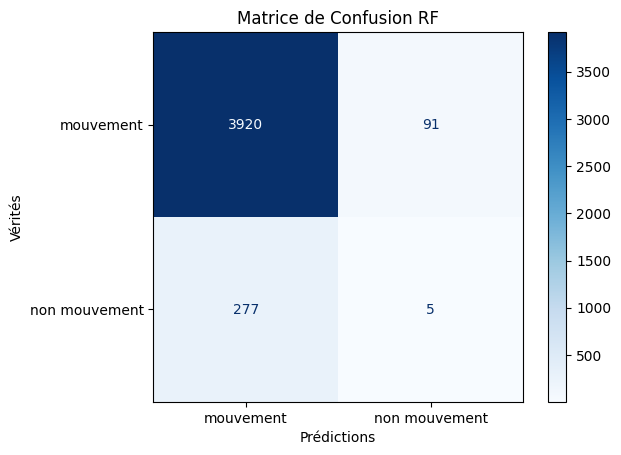

Accuracy pour seuil > 75 : 0.61
Matrice de confusion seuil à 75 : [[8176 5117]
 [ 489  525]]


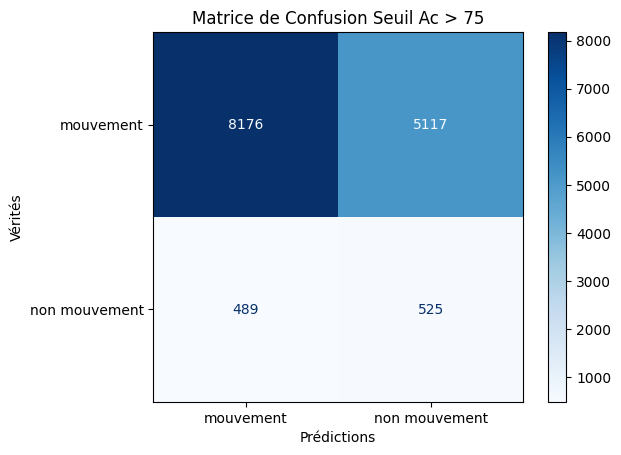

c:\Users\roman\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\roman\AppData\Local\Temp\ipykernel_66888\2245058133.py:84: DeprecationWarning: Support for non-numeric arrays has been deprecated as of SciPy 1.9.0 and will be removed in 1.11.0. `pandas.DataFrame.mode` can be used instead, see https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.mode.html.
  majority_class = mode(Y_flat[mask], keepdims=True).mode[0]


Accuracy pour clustering : 0.93
Matrice de confusion clustering : [[13293     0]
 [ 1014     0]]


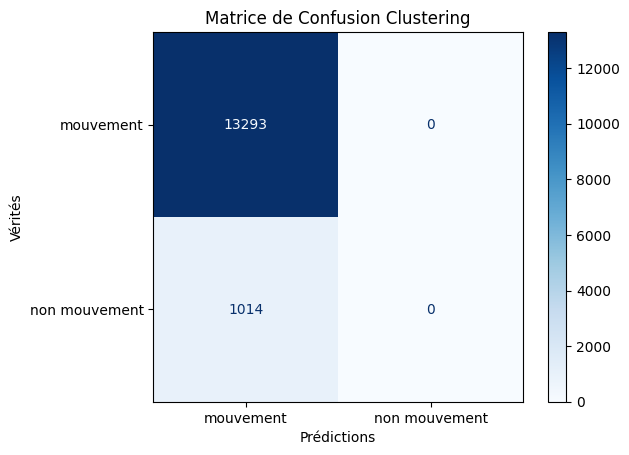

In [ ]:
import matplotlib.pyplot as plt

# Convertir en array pour faciliter le filtrage
X_array = np.array(X_dom)
Y_array = np.array(Y_dom)
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask = Y_array != None
# Appliquer le masque
X_clean = X_array[mask]
Y_clean = Y_array[mask]

# Aplatir les données (mettre au bon format pour les modèles)
X_flat = np.vstack(X_clean)  # (n_total_samples, n_features)
Y_flat = np.hstack(Y_clean)  # (n_total_samples,)


#*************************************** Random Forest *****************************************************************
# Split data into train and test samples
X_train, X_test, y_train, y_test = train_test_split(X_flat, Y_flat, test_size=0.3, random_state=42)

# Initialize the model
non_dom_Random_Forest = RandomForestClassifier(n_estimators=100, random_state=42)
# Train the model
non_dom_Random_Forest.fit(X_train, y_train)
# Test the model
y_pred = non_dom_Random_Forest.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy pour RF : {accuracy:.2f}")

cm_RF = confusion_matrix(y_test, y_pred)
# Afficher la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm_RF, display_labels= ["mouvement", "non mouvement"])
disp.plot(cmap="Blues")
disp.ax_.set_title("Matrice de Confusion RF")
disp.ax_.set_xlabel("Prédictions")
disp.ax_.set_ylabel("Vérités")
#disp.figure_.show()
plt.show()

#********************************* Seuil AC > 75 **********************************************************************************
#On a X_dom et Y_dom : construire un Y_pred_2 et le comparer à Y_dom
Y_pred_75 = []

for idx_data in range(0, len(X_clean)-1):
    seuil = X_clean[idx_data] + X_clean[idx_data+1]
    if seuil >= 75 :
        Y_pred_75.append("mouvement")
    elif seuil < 75 :
        Y_pred_75.append("non mouvement")
    else:
        Y_pred_75.append(None)

#Le dernier de Y_pred_75 ne peut pas se joindre à 2 sec avec la valeur d'après
Y_pred_75.append("non mouvement")

# Evaluate the model
accuracy = accuracy_score(Y_clean, Y_pred_75)
print(f"Accuracy pour seuil > 75 : {accuracy:.2f}")
cm_75 = confusion_matrix(Y_clean, Y_pred_75)

# Afficher la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm_75, display_labels= ["mouvement", "non mouvement"])
disp.plot(cmap="Blues")
disp.ax_.set_title("Matrice de Confusion Seuil Ac > 75")
disp.ax_.set_xlabel("Prédictions")
disp.ax_.set_ylabel("Vérités")
#disp.figure_.show()
plt.show()

#********************************* Clustering **********************************************************************************
# Supposons que X_clean est ton jeu de données (n_samples, n_features)
k = 2  # nombre de clusters (par exemple : allumé vs éteint)
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_flat)

# Créer un tableau pour mapper chaque cluster à la classe dominante
labels_map = {}
for cluster_id in np.unique(clusters):
    mask = clusters == cluster_id
    majority_class = mode(Y_flat[mask], keepdims=True).mode[0]
    labels_map[cluster_id] = majority_class
# Traduire les clusters en classes
predicted_labels = np.array([labels_map[c] for c in clusters])

# Evaluate the model
accuracy = accuracy_score(Y_flat, predicted_labels)
print(f"Accuracy pour clustering : {accuracy:.2f}")
cm_cluster = confusion_matrix(Y_flat, predicted_labels) # //////////////:: a modifier car cluster 0 peut etre mvt ou noon mvt, il faut leur donner des noms

# Afficher la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cluster, display_labels= ["mouvement", "non mouvement"])
disp.plot(cmap="Blues")
disp.ax_.set_title("Matrice de Confusion Clustering")
disp.ax_.set_xlabel("Prédictions")
disp.ax_.set_ylabel("Vérités")
#disp.figure_.show()
plt.show()
